In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
daten = {
    "title": ["ML Engineer", "Data Scientist", "AI Researcher"],
    "company": ["Google", "OpenAI", "DeepMind"],
    "remote": [True, True, False]
}

df = pd.DataFrame(daten)
df

,title,company,remote
0,ML Engineer,Google,True
1,Data Scientist,OpenAI,True
2,AI Researcher,DeepMind,False


In [3]:
df.shape

(3, 3)

In [4]:
df.types

AttributeError: 'DataFrame' object has no attribute 'types'

In [5]:
df.dtypes

title       str
company     str
remote     bool
dtype: object

In [6]:
df.head(2)

,title,company,remote
0,ML Engineer,Google,True
1,Data Scientist,OpenAI,True


In [7]:
import numpy as np

daten2 = {
    "title": ["ML Engineer", "Data Scientist", None, "AI Engineer"],
    "company": ["Google", None, "DeepMind", "Meta"],
    "remote": [True, True, False, None]
}

df2 = pd.DataFrame(daten2)
df2

,title,company,remote
0,ML Engineer,Google,True
1,Data Scientist,NaN,True
2,NaN,DeepMind,False
3,AI Engineer,Meta,None


In [8]:
df2.isnull().sum()

title      1
company    1
remote     1
dtype: int64

In [9]:
# Strategie 1: fehlende Werte ersetzen
df2.fillna("Unknown")

,title,company,remote
0,ML Engineer,Google,True
1,Data Scientist,Unknown,True
2,Unknown,DeepMind,False
3,AI Engineer,Meta,Unknown


In [10]:
# Strategie 2: Zeilen mit fehlenden Werten entfernen
df2.dropna()

,title,company,remote
0,ML Engineer,Google,True


In [11]:
df2

,title,company,remote
0,ML Engineer,Google,True
1,Data Scientist,NaN,True
2,NaN,DeepMind,False
3,AI Engineer,Meta,None


In [12]:
df = pd.read_csv("../data/raw/jobs_2026_05.csv")

In [13]:
df

,title,company,location,remote,description
0,AI & Machine Learning Engineer,Computer Futures,Deutschlandweit,True,"LLMs, LangChain, LangGraph, Prompt Engineering..."
1,Remote Applied AI Engineer,Amigo,Europe,True,"Python, typing, external APIs, LLMs, prompt en..."
2,KI-Entwickler,rumble GmbH,Dortmund,False,"KI-APIs, Automatisierungsplattformen, Machine ..."
3,AI Data Engineer,Bechtle AG,Neckarsulm,True,"Python, Docker, Kubernetes, REST-APIs, CI/CD, ..."
4,AI Engineer,Akkodis,München,False,"LLMs, Multi-Agenten, RAG, LangChain, GitHub Co..."


In [14]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(5, 5)
title           str
company         str
location        str
remote         bool
description     str
dtype: object
title          0
company        0
location       0
remote         0
description    0
dtype: int64


In [15]:
SKILLS = [
    "python", "llm", "llms", "langchain", "langgraph",
    "prompt engineering", "rag", "docker", "kubernetes",
    "machine learning", "api", "multi-agenten"
]

def skills_extrahieren(text):
    text = text.lower()
    return [skill for skill in SKILLS if skill in text]

df["skills"] = df["description"].apply(skills_extrahieren)
df[["title", "skills"]]

,title,skills
0,AI & Machine Learning Engineer,"[llm, llms, langchain, langgraph, prompt engin..."
1,Remote Applied AI Engineer,"[python, llm, llms, prompt engineering, api]"
2,KI-Entwickler,"[llm, llms, machine learning, api]"
3,AI Data Engineer,"[python, llm, llms, rag, docker, kubernetes, a..."
4,AI Engineer,"[llm, llms, langchain, rag, multi-agenten]"


In [16]:
df["description"][1]

'Python, typing, external APIs, LLMs, prompt engineering, reliability systems'

In [17]:
SKILLS = [
    "python", "llms", "langchain", "langgraph",
    "prompt engineering", "rag", "docker", "kubernetes",
    "machine learning", "api", "multi-agenten"
]

df["skills"] = df["description"].apply(skills_extrahieren)
df[["title", "skills"]]

,title,skills
0,AI & Machine Learning Engineer,"[llms, langchain, langgraph, prompt engineering]"
1,Remote Applied AI Engineer,"[python, llms, prompt engineering, api]"
2,KI-Entwickler,"[llms, machine learning, api]"
3,AI Data Engineer,"[python, llms, rag, docker, kubernetes, api, m..."
4,AI Engineer,"[llms, langchain, rag, multi-agenten]"


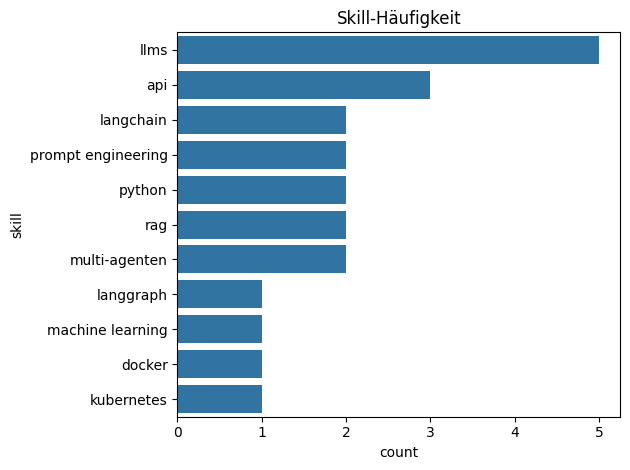

In [18]:
from collections import Counter

alle_skills = [skill for liste in df["skills"] for skill in liste]
skill_counts = Counter(alle_skills)

skill_df = pd.DataFrame(skill_counts.most_common(), columns=["skill", "count"])

sns.barplot(data=skill_df, x="count", y="skill")
plt.title("Skill-Häufigkeit")
plt.tight_layout()
plt.show()

In [1]:
import json

with open("../data/raw/hn_jobs.json", encoding="utf-8") as f:
    jobs = json.load(f)

print(f"Anzahl: {len(jobs)}")
print("\nErster Eintrag:")
print(jobs[0]["text"][:500])

Anzahl: 51

Erster Eintrag:
Turquoise| Platform Operations Engineers| Remote, USA<p>Turquoise a series C healthtech company is recruiting for two platform engineers to join the newly created platform operations team. You can expect to work closely with our Data Engineering team based in Europe, drive observability, define the metrics for reliability and help to share our platform infrastructure.<p>Click on one of the following links best aligned with your exp to apply:<p>Platform Operations Engineer-<a href="https:&#x2F;&#


In [2]:
import html
import re

def bereinige_text(text):
    if not text:
        return ""
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

print(bereinige_text(jobs[0]["text"][:500]))

Turquoise| Platform Operations Engineers| Remote, USA Turquoise a series C healthtech company is recruiting for two platform engineers to join the newly created platform operations team. You can expect to work closely with our Data Engineering team based in Europe, drive observability, define the metrics for reliability and help to share our platform infrastructure. Click on one of the following links best aligned with your exp to apply: Platform Operations Engineer-<a href="https:/&#


In [3]:
print(bereinige_text(jobs[0]["text"]))

Turquoise| Platform Operations Engineers| Remote, USA Turquoise a series C healthtech company is recruiting for two platform engineers to join the newly created platform operations team. You can expect to work closely with our Data Engineering team based in Europe, drive observability, define the metrics for reliability and help to share our platform infrastructure. Click on one of the following links best aligned with your exp to apply: Platform Operations Engineer- https://jobs.ashbyhq.com/turquoise-health/f4bcb7df-4e4b-468d... Senior Platform Operations Engineer- https://jobs.ashbyhq.com/turquoise-health/f6a6e00f-c383-4f3e...


In [4]:
for job in jobs:
    job["text_clean"] = bereinige_text(job["text"])

print(f"Bereinigt: {len(jobs)} Einträge")
print("\nBeispiel:")
print(jobs[0]["text_clean"][:300])

Bereinigt: 51 Einträge

Beispiel:
Turquoise| Platform Operations Engineers| Remote, USA Turquoise a series C healthtech company is recruiting for two platform engineers to join the newly created platform operations team. You can expect to work closely with our Data Engineering team based in Europe, drive observability, define the me


In [5]:
with open("../data/raw/hn_jobs_clean.json", "w", encoding="utf-8") as f:
    json.dump(jobs, f, indent=2, ensure_ascii=False)

print("Gespeichert: data/raw/hn_jobs_clean.json")

Gespeichert: data/raw/hn_jobs_clean.json
